# Panant daily salt anomaly

In [6]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [9]:
lat_slice = slice(-79,-59)

# Importing data
paths_C = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-daily-pan01_test_01-986f8f63/output000/20010101.ocean_daily_z_*.nc'))
paths_M = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-daily-expt-2f759912/output000/20010101.ocean_daily_z_*.nc'))

In [43]:
# Time variant variables
def preprocess(ds):
    ds = ds[['so','S_advection_xy','Sh_tendency_vert_remap','osalttend','osaltpmdiff','osaltdiff','boundary_forcing_salt_tendency']].sel(yh=lat_slice)
    return ds

cont = xr.open_mfdataset(paths_C, preprocess = preprocess, chunks = 'auto')
melt = xr.open_mfdataset(paths_M, preprocess = preprocess, chunks = 'auto')

In [44]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [45]:
depth = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['deptho']
land_mask = (0 * depth).fillna(1)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom6_01')

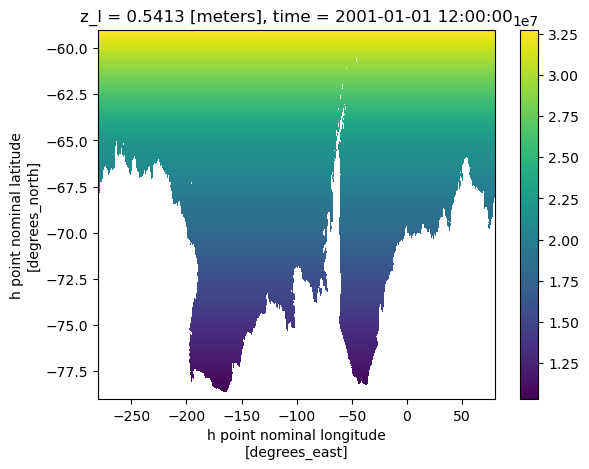

In [46]:
# Doing spatial average
area = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['areacello']
var = cont.so.isel(time=0).isel(z_l=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [47]:
# Salinity variable
saltC = cont['so'].isel(z_l=0)
saltM = melt['so'].isel(z_l=0)

In [48]:
shelf_salt_cont = saltC.where(shelf_mask == 1)
shelf_salt_pert = saltM.where(shelf_mask == 1)
shelf_salt_cont

<xarray.DataArray 'so' (time: 3, yh: 460, xh: 3600)> Size: 20MB
dask.array<where, shape=(3, 460, 3600), dtype=float32, chunksize=(1, 313, 1545), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 24B 2001-01-01 12:00:00 ... 2001-01-03 12:00:00
  * yh       (yh) float64 4kB -79.0 -78.95 -78.91 ... -59.14 -59.08 -59.03
  * xh       (xh) float64 29kB -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95
    z_l      float64 8B 0.5413
Attributes:
    units:          psu
    long_name:      Sea Water Salinity
    cell_methods:   area:mean z_l:mean yh:mean xh:mean time: mean
    cell_measures:  volume: volcello area: areacello
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_salinity

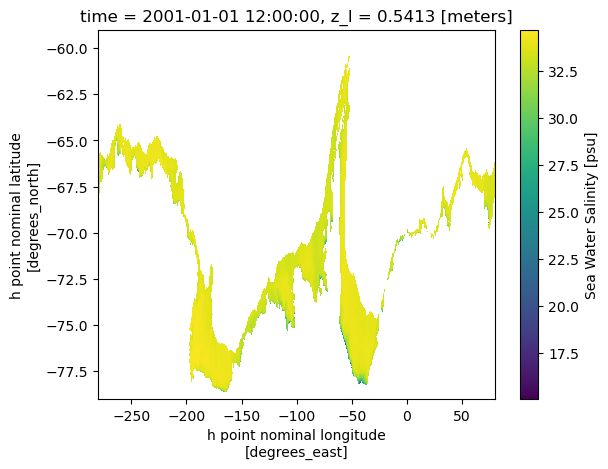

In [49]:
shelf_salt_cont.isel(time=0).plot()

In [50]:
# Spatial average
topsalt_cont_time = (area_corr * shelf_salt_cont).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
topsalt_pert_time = (area_corr * shelf_salt_pert).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])

In [51]:
topsalt_cont_time

<xarray.DataArray (time: 3)> Size: 12B
dask.array<truediv, shape=(3,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 24B 2001-01-01 12:00:00 ... 2001-01-03 12:00:00
    z_l      float64 8B 0.5413

In [52]:
topsalt_cont_time = topsalt_cont_time.load()

In [53]:
topsalt_pert_time = topsalt_pert_time.load()

Text(0.5, 1.0, 'Pan01 Time Series of Surface Salinity on Shelf')

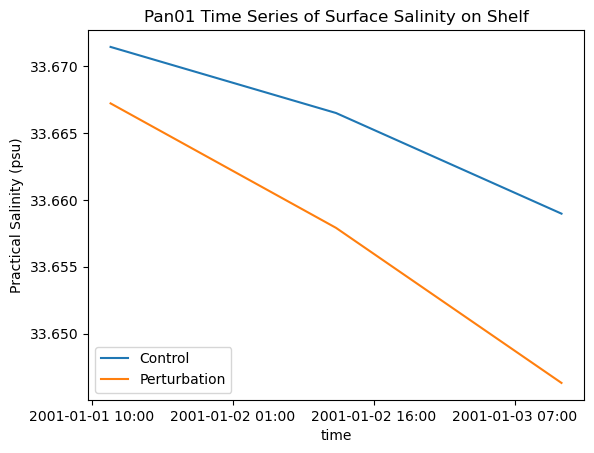

In [54]:
topsalt_cont_time.plot(label="Control")
topsalt_pert_time.plot(label="Perturbation")
#plt.xlim(380,4000)
#plt.ylim(-1.30,-0.70)
plt.ylabel("Practical Salinity (psu)")
plt.legend(loc="lower left")
plt.title("Pan01 Time Series of Surface Salinity on Shelf")

Text(0.5, 1.0, 'Pan01 Time Series of Surface Salinity on Shelf')

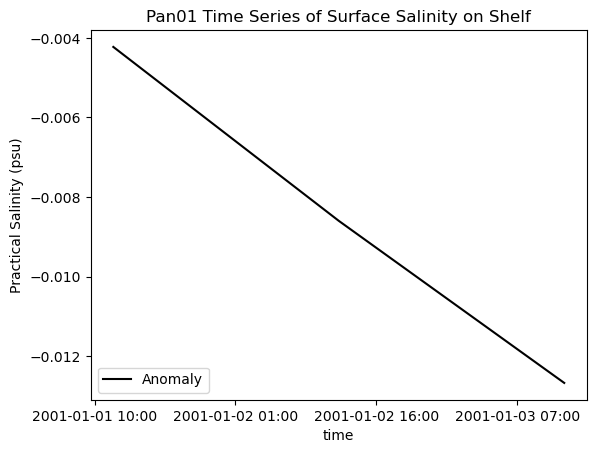

In [55]:
(topsalt_pert_time-topsalt_cont_time).plot(label="Anomaly",color='black')
#plt.xlim(380,4000)
#plt.ylim(-1.30,-0.70)
plt.ylabel("Practical Salinity (psu)")
plt.legend(loc="lower left")
plt.title("Pan01 Time Series of Surface Salinity on Shelf")

# Looking at individual diagnostics

In [56]:
# testing individual diagnostics
tendency_C = cont.osalttend
adv_horizontal_C = cont.S_advection_xy
adv_vertical_C = cont.Sh_tendency_vert_remap
surface_forcing_C = cont.boundary_forcing_salt_tendency
diff_1_C = cont.osaltdiff
diff_2_C = cont.osaltpmdiff

tendency_M = melt.osalttend
adv_horizontal_M = melt.S_advection_xy
adv_vertical_M = melt.Sh_tendency_vert_remap
surface_forcing_M = melt.boundary_forcing_salt_tendency
diff_1_M = melt.osaltdiff
diff_2_M = melt.osaltpmdiff

In [58]:
zdim = 'z_l'

In [59]:
tendency_plot_C = tendency_C.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
adv_hor_plot_C = adv_horizontal_C.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
adv_vert_plot_C = adv_vertical_C.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
surface_plot_C = surface_forcing_C.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
diff_1_plot_C = diff_1_C.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
diff_2_plot_C = diff_2_C.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()

In [60]:
tendency_plot_M = tendency_M.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
adv_hor_plot_M = adv_horizontal_M.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
adv_vert_plot_M = adv_vertical_M.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
surface_plot_M = surface_forcing_M.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
diff_1_plot_M = diff_1_M.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
diff_2_plot_M = diff_2_M.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()

In [61]:
tendency_plot_C = tendency_plot_C.compute()
adv_hor_plot_C = adv_hor_plot_C.compute()
adv_vert_plot_C = adv_vert_plot_C.compute()
surface_plot_C = surface_plot_C.compute()
diff_1_plot_C = diff_1_plot_C.compute()
diff_2_plot_C = diff_2_plot_C.compute()

In [62]:
tendency_plot_M = tendency_plot_M.compute()
adv_hor_plot_M = adv_hor_plot_M.compute()
adv_vert_plot_M = adv_vert_plot_M.compute()
surface_plot_M = surface_plot_M.compute()
diff_1_plot_M = diff_1_plot_M.compute()
diff_2_plot_M = diff_2_plot_M.compute()

In [63]:
tendency_ave_C = (area_corr * tendency_plot_C).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
adv_hor_ave_C = (area_corr * adv_hor_plot_C).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
adv_vert_ave_C = (area_corr * adv_vert_plot_C).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
surface_ave_C = (area_corr * surface_plot_C).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
diff_1_ave_C = (area_corr * diff_1_plot_C).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
diff_2_ave_C = (area_corr * diff_2_plot_C).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])

In [64]:
tendency_ave_M = (area_corr * tendency_plot_M).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
adv_hor_ave_M = (area_corr * adv_hor_plot_M).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
adv_vert_ave_M = (area_corr * adv_vert_plot_M).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
surface_ave_M = (area_corr * surface_plot_M).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
diff_1_ave_M = (area_corr * diff_1_plot_M).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])
diff_2_ave_M = (area_corr * diff_2_plot_M).sum(['xh', 'yh']) / area_corr.where(shelf_mask == 1).sum(['xh', 'yh'])

In [65]:
tendency_ave_C = tendency_ave_C.load()
adv_hor_ave_C = adv_hor_ave_C.load()
adv_vert_ave_C = adv_vert_ave_C.load()
surface_ave_C = surface_ave_C.load()
diff_1_ave_C = diff_1_ave_C.load()
diff_2_ave_C = diff_2_ave_C.load()

In [66]:
tendency_ave_M = tendency_ave_M.load()
adv_hor_ave_M = adv_hor_ave_M.load()
adv_vert_ave_M = adv_vert_ave_M.load()
surface_ave_M = surface_ave_M.load()
diff_1_ave_M = diff_1_ave_M.load()
diff_2_ave_M = diff_2_ave_M.load()

In [67]:
print(
    "tendency =", tendency_ave_C.values,
    "\nhorizontal advection =", adv_hor_ave_C.values,
    "\nvertical advection =", adv_vert_ave_C.values,
    "\nsurface forcing =", surface_ave_C.values,
    "\ndiffusion 1 =", diff_1_ave_C.values,
    "\ndiffusion 2 =", diff_2_ave_C.values
)

tendency = -3.5462617e-06 
horizontal advection = -4.224966e-06 
vertical advection = 1.7143548e-12 
surface forcing = 6.787037e-07 
diffusion 1 = -4.0369e-16 
diffusion 2 = 0.0


In [68]:
print(
    "tendency =", tendency_ave_M.values,
    "\nhorizontal advection =", adv_hor_ave_M.values,
    "\nvertical advection =", adv_vert_ave_M.values,
    "\nsurface forcing =", surface_ave_M.values,
    "\ndiffusion 1 =", diff_1_ave_M.values,
    "\ndiffusion 2 =", diff_2_ave_M.values
)

tendency = -3.6953506e-06 
horizontal advection = -4.3788536e-06 
vertical advection = -1.3211798e-12 
surface forcing = 6.8350494e-07 
diffusion 1 = 3.1500022e-15 
diffusion 2 = 0.0
